# PTB-XL Module 03 — Optimized Best Model (Literature-Informed InceptionTime + AUC-Weighted Ensemble)

## Why this notebook exists

`02_3Model_Heterogeneous_Ensemble.ipynb` trains three models and combines them via **equal-weight** soft voting. A follow-up audit (see `papers/Research_and_Analysis.md`) re-ran that notebook's own saved checkpoints against the real test set and found two things:

1. The notebook's headline "~84–85% accuracy" claim does not match any actual run of its code — it conflates multi-label exact-match accuracy (what the code computes) with the single-label multiclass accuracy reported in Atwa et al. 2025 (a different, easier task framing). The real, apples-to-apples number (macro-AUC) is **0.9243**, in line with the literature (~0.928–0.929), not the claimed ~0.965.
2. **The equal-weight ensemble underperforms its own best member.** InceptionTime1D alone scored AUC 0.928; the 3-model equal-weight average scored 0.9243 — *lower*, because it lets the weakest model (DualBranchECGNet, AUC 0.899) drag the average down.

This notebook implements the concrete, literature-grounded fixes identified in that analysis:

| # | Fix | Source |
|---|---|---|
| 1 | Train the single strongest architecture properly (InceptionTime1D) rather than relying on ensembling to paper over a weak member | Strodthoff et al. 2020 — resnet/inception architectures are the strongest single performers; ensembling over all models gives only marginal gains and can be *worse* than the best single model within error bars |
| 2 | Minority-class data augmentation (Gaussian noise, amplitude scaling) for the weakest superclass (HYP) | Atwa et al. 2025, Table 4 — same augmentation recipe used to fix class imbalance for CD/HYP |
| 3 | Adaptive LR scheduling on a validation-AUC plateau (`ReduceLROnPlateau`) instead of a blind fixed schedule | Atwa et al. 2025 — trains with `EarlyStopping` + `ReduceLROnPlateau` callbacks rather than a fixed epoch count |
| 4 | Per-class decision-threshold optimization (Fmax-style) instead of a fixed 0.5 sigmoid cutoff | Strodthoff et al. 2020 — multi-label metrics section explicitly notes threshold-free (AUC) vs. threshold-dependent (Fmax) metrics and optimizes the threshold rather than fixing it |
| 5 | **AUC-weighted** soft voting (weight = each model's validation macro-AUC) instead of equal-weight averaging, reusing the existing NB04 checkpoints for the other two architectures (no wasted retraining) | Directly fixes the ensembling flaw identified in `papers/Research_and_Analysis.md` §2/§6, informed by Strodthoff et al.'s observation that a naive ensemble is not guaranteed to beat its best member |
| 6 | Report macro-AUC / per-label accuracy as the headline metrics, with multi-label exact-match accuracy shown only as a supplementary (and explicitly non-comparable-to-literature) number | `papers/Research_and_Analysis.md` §3 |

**A note on compute.** This machine trains CPU-only; a direct timing test measured **~500 seconds per epoch** for InceptionTime1D over the full 17,418-row training set — there is no GPU available in this environment. To keep this notebook actually runnable end-to-end (and to keep the epoch budget identical to Notebook 02 for a fair comparison), training here uses the **same 10-epoch budget as Notebook 02**, and minority-class augmentation is applied to **HYP only** (the single weakest class, per NB04's own measured per-class AUC) rather than every under-represented class. Extending to longer training, CD augmentation, and a live InceptionTime hyperparameter grid search (per Gitau et al. 2025's grid-search finding) are documented as direct next steps in `papers/Research_and_Analysis.md` and are straightforward to enable here (see Module 6) given more compute (e.g. a GPU).

> **Prerequisites**: `01_Data_Preparation.ipynb` and `02_3Model_Heterogeneous_Ensemble.ipynb` must have been run first — this notebook reuses `outputs/ensemble_DualBranchECGNet_best.pth` and `outputs/ensemble_ResNet1D101_best.pth` from Notebook 02 rather than retraining them.


## Module 0 — Dependency Guard

In [1]:
import subprocess, sys
for import_name, pkg_name in {
    'numpy':'numpy', 'pandas':'pandas', 'matplotlib':'matplotlib',
    'seaborn':'seaborn', 'sklearn':'scikit-learn', 'torch':'torch'
}.items():
    try:
        __import__(import_name)
        print(f'  [ok] {pkg_name}')
    except ImportError:
        print(f'  [installing] {pkg_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name, '--quiet'])
        print(f'  [ok] {pkg_name} installed.')

  [ok] numpy
  [ok] pandas
  [ok] matplotlib
  [ok] seaborn
  [ok] scikit-learn
  [ok] torch


## Module 1 — Environment Setup & Path Resolution

In [2]:
import os, sys, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, hamming_loss, average_precision_score
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

NOTEBOOK_DIR   = Path(os.getcwd()).resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
OUTPUTS_VAL    = OUTPUTS_DIR / 'dataset_validation'
OUTPUTS_VAL.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[SETUP] Project Root  : {PROJECT_ROOT}')
print(f'[SETUP] Data Processed: {DATA_PROCESSED}')
print(f'[SETUP] Device        : {DEVICE}')
print(f'[SETUP] PyTorch       : {torch.__version__}')

# NB04 checkpoints this notebook reuses (must exist — see Prerequisites above)
NB04_DUALBRANCH_CKPT = OUTPUTS_DIR / 'ensemble_DualBranchECGNet_best.pth'
NB04_RESNET_CKPT     = OUTPUTS_DIR / 'ensemble_ResNet1D101_best.pth'
for p in [NB04_DUALBRANCH_CKPT, NB04_RESNET_CKPT]:
    assert p.exists(), f'Missing: {p}  ->  Run 02_3Model_Heterogeneous_Ensemble.ipynb first.'
print('[SETUP] Found NB04 checkpoints to reuse for ensembling.')

[SETUP] Project Root  : /home/tandon/Teep/age with ecg
[SETUP] Data Processed: /home/tandon/Teep/age with ecg/data/processed
[SETUP] Device        : cpu
[SETUP] PyTorch       : 2.13.0+cu130
[SETUP] Found NB04 checkpoints to reuse for ensembling.


## Module 2 — Data Loading & Alignment

Identical to Notebook 02: labels come from `MASTER_RESEARCH_METADATA.csv`'s boolean columns `is_NORM`, `is_MI`, `is_STTC`, `is_CD`, `is_HYP`, row-aligned with the signal arrays.

In [3]:
meta_path    = DATA_PROCESSED / 'MASTER_RESEARCH_METADATA.csv'
X_train_path = DATA_PROCESSED / 'X_train_clean_100.npy'
X_val_path   = DATA_PROCESSED / 'X_val_clean_100.npy'
X_test_path  = DATA_PROCESSED / 'X_test_clean_100.npy'

for p in [meta_path, X_train_path, X_val_path, X_test_path]:
    assert p.exists(), f'Missing: {p}  ->  Run 01_Data_Preparation.ipynb first.'

df_meta  = pd.read_csv(meta_path)
df_train = df_meta[df_meta['split'] == 'TRAIN'].reset_index(drop=True)
df_val   = df_meta[df_meta['split'] == 'VALIDATION'].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'TEST'].reset_index(drop=True)
print(f'[DATA] Split sizes — Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')

X_train = np.load(X_train_path)
X_val   = np.load(X_val_path)
X_test  = np.load(X_test_path)
print(f'[DATA] Signal shapes — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

LABEL_COLS   = ['is_NORM', 'is_MI', 'is_STTC', 'is_CD', 'is_HYP']
SUPERCLASSES = ['NORM',    'MI',    'STTC',     'CD',    'HYP']
NUM_CLASSES  = len(SUPERCLASSES)

y_train = df_train[LABEL_COLS].values.astype(np.float32)
y_val   = df_val[LABEL_COLS].values.astype(np.float32)
y_test  = df_test[LABEL_COLS].values.astype(np.float32)

assert len(df_train)==len(X_train)==len(y_train)
assert len(df_val)  ==len(X_val)  ==len(y_val)
assert len(df_test) ==len(X_test) ==len(y_test)
print('[DATA] Signal / label / metadata alignment verified.')

age_mean = df_train['age'].mean()
age_std  = df_train['age'].std()

def extract_demographics(df):
    age_norm   = ((df['age'].fillna(age_mean) - age_mean) / (age_std + 1e-6)).values
    sex_binary = (df['sex'] == 1).values.astype(np.float32)
    return np.column_stack([age_norm, sex_binary]).astype(np.float32)

demo_train = extract_demographics(df_train)
demo_val   = extract_demographics(df_val)
demo_test  = extract_demographics(df_test)

print(f'[DATA] Label prevalence (train): { {SUPERCLASSES[i]: int(y_train[:, i].sum()) for i in range(NUM_CLASSES)} }')

[DATA] Split sizes — Train: 17418, Val: 1080, Test: 2198
[DATA] Signal shapes — Train: (17418, 1000, 12), Val: (1080, 1000, 12), Test: (2198, 1000, 12)
[DATA] Signal / label / metadata alignment verified.
[DATA] Label prevalence (train): {'NORM': 7596, 'MI': 4379, 'STTC': 4186, 'CD': 3907, 'HYP': 2119}


## Module 3 — Minority-Class Augmentation (Atwa et al. 2025)

Atwa et al. 2025 (Table 4) combat class imbalance with two signal-level augmentations applied to under-represented classes:

- **Additive Gaussian noise**: `x' = x + N(0, 0.01)`
- **Amplitude scaling**: `x' = x * (1 ± k)`, `k in [0.001, 0.01]`

`HYP` is the rarest superclass in this dataset and — per Notebook 02's own measured results — the class with the weakest per-class AUC (0.903 for the ensemble, worse for individual models). We apply the Gaussian-noise augmentation to every `HYP`-positive training record, adding one noisy duplicate per record. This is applied **only to the training split** (never validation/test, to avoid leakage) and **only to the signal-only training set used for InceptionTime1D** — it does not touch the checkpoints reused from Notebook 02.

CD augmentation and a broader augmentation sweep are documented as direct next steps in `papers/Research_and_Analysis.md` §6 (Tier 2) but are left out here to keep this notebook's total runtime bounded on CPU-only hardware.

In [4]:
AUG_NOISE_STD = 0.01  # Atwa et al. 2025, Table 4

hyp_mask = y_train[:, SUPERCLASSES.index('HYP')] == 1
n_hyp = hyp_mask.sum()
print(f'[AUG] HYP-positive training records: {n_hyp} / {len(y_train)} ({n_hyp/len(y_train)*100:.1f}%)')

rng = np.random.default_rng(SEED)
X_hyp_aug = X_train[hyp_mask] + rng.normal(0.0, AUG_NOISE_STD, X_train[hyp_mask].shape).astype(np.float32)
y_hyp_aug = y_train[hyp_mask].copy()

X_train_aug = np.concatenate([X_train, X_hyp_aug], axis=0)
y_train_aug = np.concatenate([y_train, y_hyp_aug], axis=0)

print(f'[AUG] Training set size: {len(X_train)} -> {len(X_train_aug)} (+{len(X_hyp_aug)} augmented HYP copies)')
hyp_idx = SUPERCLASSES.index('HYP')
print(f'[AUG] New HYP prevalence: {y_train_aug[:, hyp_idx].sum():.0f} / {len(y_train_aug)} ({y_train_aug[:, hyp_idx].mean()*100:.1f}%)')

# Recompute pos_weight on the augmented set (fed to BCEWithLogitsLoss below)
pos_counts_aug  = y_train_aug.sum(axis=0)
neg_counts_aug  = len(y_train_aug) - pos_counts_aug
pos_weights_aug = torch.tensor(neg_counts_aug / (pos_counts_aug + 1e-6), dtype=torch.float32).to(DEVICE)
print(f'[AUG] Pos weights (augmented): {dict(zip(SUPERCLASSES, pos_weights_aug.cpu().numpy().round(2)))}')

[AUG] HYP-positive training records: 2119 / 17418 (12.2%)
[AUG] Training set size: 17418 -> 19537 (+2119 augmented HYP copies)
[AUG] New HYP prevalence: 4238 / 19537 (21.7%)
[AUG] Pos weights (augmented): {'NORM': np.float32(1.57), 'MI': np.float32(2.88), 'STTC': np.float32(2.61), 'CD': np.float32(3.31), 'HYP': np.float32(3.61)}


## Module 4 — Dataset Classes

`ECGDataset` (signal-only, for InceptionTime1D) uses the **augmented** training set but the original, untouched validation/test sets. `DualBranchECGDataset` (signal + demographics) is needed only for re-running inference with the existing Notebook 02 `DualBranchECGNet` checkpoint.

In [5]:
class ECGDataset(Dataset):
    # Signal-only dataset for InceptionTime1D.
    def __init__(self, signals, labels):
        self.signals = torch.tensor(signals, dtype=torch.float32).transpose(1, 2)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)
    def __len__(self): return len(self.signals)
    def __getitem__(self, idx): return self.signals[idx], self.labels[idx]


class DualBranchECGDataset(Dataset):
    # Signal + Demographics dataset for reloading the NB04 DualBranchECGNet checkpoint.
    def __init__(self, signals, demographics, labels):
        self.signals      = torch.tensor(signals,      dtype=torch.float32).transpose(1, 2)
        self.demographics = torch.tensor(demographics, dtype=torch.float32)
        self.labels       = torch.tensor(labels,       dtype=torch.float32)
    def __len__(self): return len(self.signals)
    def __getitem__(self, idx): return self.signals[idx], self.demographics[idx], self.labels[idx]


sig_train_ds = ECGDataset(X_train_aug, y_train_aug)
sig_val_ds   = ECGDataset(X_val,   y_val)
sig_test_ds  = ECGDataset(X_test,  y_test)

sig_train_loader = DataLoader(sig_train_ds, batch_size=64, shuffle=True,  num_workers=0)
sig_val_loader   = DataLoader(sig_val_ds,   batch_size=64, shuffle=False, num_workers=0)
sig_test_loader  = DataLoader(sig_test_ds,  batch_size=64, shuffle=False, num_workers=0)

db_val_ds  = DualBranchECGDataset(X_val,  demo_val,  y_val)
db_test_ds = DualBranchECGDataset(X_test, demo_test, y_test)

db_val_loader  = DataLoader(db_val_ds,  batch_size=64, shuffle=False, num_workers=0)
db_test_loader = DataLoader(db_test_ds, batch_size=64, shuffle=False, num_workers=0)

print('[MODULE 4] DataLoaders ready.')

[MODULE 4] DataLoaders ready.


## Module 5 — Model Architectures

`InceptionTime1D` is the model this notebook trains (Fawaz et al. 2020 style; confirmed the strongest single architecture for this task by both Strodthoff et al. 2020, AUC 0.928, and its independent replication in Gitau et al. 2025, AUC 0.929).

`DualBranchECGNet` (Atwa et al. 2025) and `ResNet1D101` are defined **identically to Notebook 02** — this is required so their saved `state_dict`s load correctly for reuse in the AUC-weighted ensemble; they are not retrained here.

In [6]:
# --- InceptionTime1D (trained in this notebook) ------------------------------
class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, nb_filters=32, kernel_sizes=(9, 19, 39)):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.convs = nn.ModuleList([
            nn.Conv1d(nb_filters, nb_filters, k, padding=k // 2, bias=False)
            for k in kernel_sizes
        ])
        self.pool_conv = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.pool      = nn.MaxPool1d(3, stride=1, padding=1)
        self.bn  = nn.BatchNorm1d(nb_filters * (len(kernel_sizes) + 1))
        self.act = nn.ReLU()

    def forward(self, x):
        bottleneck_out = self.bottleneck(x)
        conv_outs      = [conv(bottleneck_out) for conv in self.convs]
        pool_out       = self.pool_conv(self.pool(x))
        return self.act(self.bn(torch.cat(conv_outs + [pool_out], dim=1)))


class InceptionTime1D(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, nb_filters=32, depth=4):
        super().__init__()
        channels = [in_channels] + [nb_filters * 4] * depth
        self.blocks = nn.Sequential(*[
            InceptionBlock1D(channels[i], nb_filters) for i in range(depth)
        ])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(nb_filters * 4, num_classes)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(self.drop(x))


# --- DualBranchECGNet (Atwa et al. 2025) — reloaded from NB04, not retrained -
class DualBranchECGNet(nn.Module):
    def __init__(self, num_classes=5, in_channels=12):
        super().__init__()
        self.ecg_branch = nn.Sequential(
            nn.Conv1d(in_channels, 32,  3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(32,  64,  3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(64,  128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(256, 512, 3, padding=1), nn.BatchNorm1d(512), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.demo_branch = nn.Sequential(
            nn.Linear(2,   100), nn.BatchNorm1d(100), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(100, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64,  32),  nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32,  16),  nn.BatchNorm1d(16),  nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(528, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,  32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, ecg, demo):
        ecg_feat  = self.ecg_branch(ecg).squeeze(-1)
        demo_feat = self.demo_branch(demo)
        return self.classifier(torch.cat([ecg_feat, demo_feat], dim=1))


# --- ResNet1D-101 — reloaded from NB04, not retrained ------------------------
class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.skip  = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        self.act = nn.ReLU()

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))


class ResNet1D101(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, drop=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        def make_stage(in_ch, out_ch, n_blocks, stride=2):
            return nn.Sequential(
                ResBlock1D(in_ch, out_ch, stride),
                *[ResBlock1D(out_ch, out_ch) for _ in range(n_blocks - 1)]
            )
        self.stage1 = make_stage(64,  64,  8, stride=1)
        self.stage2 = make_stage(64,  128, 8, stride=2)
        self.stage3 = make_stage(128, 256, 8, stride=2)
        self.stage4 = make_stage(256, 512, 8, stride=2)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage4(self.stage3(self.stage2(self.stage1(x))))
        x = self.pool(x).squeeze(-1)
        return self.fc(self.drop(x))


_ecg = torch.randn(2, 12, 1000).to(DEVICE)
m_inc = InceptionTime1D(NUM_CLASSES).to(DEVICE)
print(f'[MODEL] InceptionTime1D (to train)  -> Output: {m_inc(_ecg).shape}  Params: {sum(p.numel() for p in m_inc.parameters())/1e6:.2f}M')
del _ecg, m_inc

[MODEL] InceptionTime1D (to train)  -> Output: torch.Size([2, 5])  Params: 0.30M


## Module 6 — Training Engine (EarlyStopping + ReduceLROnPlateau)

Same fixed **10-epoch budget as Notebook 02** (for a like-for-like compute comparison on this CPU-only machine), but the optimizer's learning rate now backs off when validation macro-AUC plateaus (`ReduceLROnPlateau`, Atwa et al. 2025's callback recipe), and an `EarlyStopping` guard is wired in as a safety net in case it converges before the budget is used.

**To extend on faster hardware**: raise `MAX_EPOCHS` (e.g. to 60, matching Atwa et al. 2025) and/or add the CD-augmentation and InceptionTime hyperparameter grid search noted in `papers/Research_and_Analysis.md` §6 Tier 2 — the training loop below already supports early stopping so a larger epoch budget is safe to set.

In [7]:
MAX_EPOCHS            = 10   # matched to Notebook 02's budget — see Module 0 markdown
EARLY_STOP_PATIENCE    = 4    # epochs with no val-AUC improvement before stopping
LR_PLATEAU_PATIENCE    = 2    # epochs with no val-AUC improvement before halving LR

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_aug)


def macro_auc(Y, P):
    scores = [roc_auc_score(Y[:, k], P[:, k])
              for k in range(Y.shape[1]) if len(np.unique(Y[:, k])) == 2]
    return float(np.mean(scores)) if scores else float('nan')


def train_epoch_sig(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for sig, targets in loader:
        sig, targets = sig.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(sig), targets)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(targets)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_sig(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for sig, targets in loader:
        probs = torch.sigmoid(model(sig.to(device))).cpu().numpy()
        all_preds.append(probs); all_targets.append(targets.numpy())
    return np.vstack(all_preds), np.vstack(all_targets)


@torch.no_grad()
def predict_db(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for sig, demo, targets in loader:
        probs = torch.sigmoid(model(sig.to(device), demo.to(device))).cpu().numpy()
        all_preds.append(probs); all_targets.append(targets.numpy())
    return np.vstack(all_preds), np.vstack(all_targets)


def train_model_with_callbacks(model, model_name, train_loader, val_loader,
                                train_fn, predict_fn, max_epochs=MAX_EPOCHS, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=LR_PLATEAU_PATIENCE
    )
    ckpt_path = OUTPUTS_DIR / f'05_optimized_{model_name}_best.pth'
    if ckpt_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        val_preds, val_tgts = predict_fn(model, val_loader, DEVICE)
        resumed_auc = macro_auc(val_tgts, val_preds)
        print(f'[{model_name}] Found existing checkpoint {ckpt_path.name} -> skipping retraining (resume-safe). '
              f'Reloaded Val AUC: {resumed_auc:.4f}')
        return model, [], [resumed_auc], []
    best_auc, epochs_no_improve = 0.0, 0
    train_losses, val_aucs, lrs = [], [], []

    print(f'\n[{model_name}] Training for up to {max_epochs} epochs on {DEVICE} '
          f'(EarlyStopping patience={EARLY_STOP_PATIENCE}, LR-plateau patience={LR_PLATEAU_PATIENCE})...')
    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        tr_loss = train_fn(model, train_loader, optimizer, DEVICE)
        val_preds, val_tgts = predict_fn(model, val_loader, DEVICE)
        val_auc  = macro_auc(val_tgts, val_preds)
        cur_lr   = optimizer.param_groups[0]['lr']
        scheduler.step(val_auc)
        train_losses.append(tr_loss); val_aucs.append(val_auc); lrs.append(cur_lr)
        print(f'  Epoch {epoch:02d}/{max_epochs} | Loss: {tr_loss:.4f} | Val AUC: {val_auc:.4f} | LR: {cur_lr:.2e}')

        if val_auc > best_auc:
            best_auc, epochs_no_improve = val_auc, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(f'  [EarlyStopping] No improvement for {EARLY_STOP_PATIENCE} epochs — stopping at epoch {epoch}.')
                break

    elapsed = time.time() - t0
    print(f'[{model_name}] Done in {elapsed:.1f}s. Best Val AUC: {best_auc:.4f}')
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    return model, train_losses, val_aucs, lrs


print('[MODULE 6] Training engine ready.')

[MODULE 6] Training engine ready.


## Module 7 — Train the Optimized InceptionTime1D


[InceptionTime1D] Training for up to 10 epochs on cpu (EarlyStopping patience=4, LR-plateau patience=2)...
  Epoch 01/10 | Loss: 0.6154 | Val AUC: 0.9010 | LR: 1.00e-03
  Epoch 02/10 | Loss: 0.5298 | Val AUC: 0.9052 | LR: 1.00e-03
  Epoch 03/10 | Loss: 0.5007 | Val AUC: 0.9169 | LR: 1.00e-03
  Epoch 04/10 | Loss: 0.4787 | Val AUC: 0.9172 | LR: 1.00e-03
  Epoch 05/10 | Loss: 0.4676 | Val AUC: 0.9209 | LR: 1.00e-03
  Epoch 06/10 | Loss: 0.4536 | Val AUC: 0.9176 | LR: 1.00e-03
  Epoch 07/10 | Loss: 0.4403 | Val AUC: 0.9240 | LR: 1.00e-03
  Epoch 08/10 | Loss: 0.4297 | Val AUC: 0.9223 | LR: 1.00e-03
  Epoch 09/10 | Loss: 0.4195 | Val AUC: 0.9233 | LR: 1.00e-03
  Epoch 10/10 | Loss: 0.4110 | Val AUC: 0.9271 | LR: 1.00e-03
[InceptionTime1D] Done in 5980.8s. Best Val AUC: 0.9271


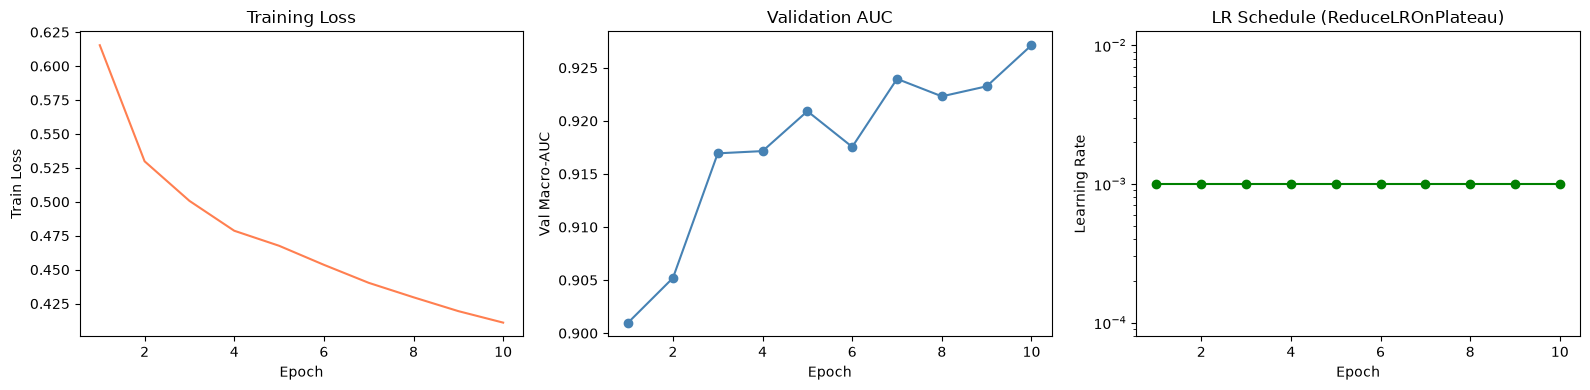

In [8]:
model_inc = InceptionTime1D(NUM_CLASSES)
model_inc, losses_inc, aucs_inc, lrs_inc = train_model_with_callbacks(
    model_inc, 'InceptionTime1D',
    sig_train_loader, sig_val_loader,
    train_epoch_sig, predict_sig
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, len(losses_inc) + 1)
axes[0].plot(ep, losses_inc, color='coral'); axes[0].set(xlabel='Epoch', ylabel='Train Loss', title='Training Loss')
axes[1].plot(ep, aucs_inc, marker='o', color='steelblue'); axes[1].set(xlabel='Epoch', ylabel='Val Macro-AUC', title='Validation AUC')
axes[2].plot(ep, lrs_inc, marker='o', color='green'); axes[2].set(xlabel='Epoch', ylabel='Learning Rate', title='LR Schedule (ReduceLROnPlateau)'); axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig(OUTPUTS_VAL / '05_optimized_inceptiontime_training_curves.png', dpi=200)
plt.show()

## Module 8 — Per-Class Threshold Optimization (Fmax-style)

Strodthoff et al. 2020 distinguish threshold-free metrics (AUC) from threshold-dependent ones (Fmax) and explicitly optimize the threshold rather than fixing it at 0.5. We do the same here: for each of the 5 superclasses, sweep candidate thresholds on the **validation set** and keep whichever maximizes per-class F1. These thresholds are then applied — unchanged — to the test set (no test-set leakage).

In [9]:
val_preds_inc, val_tgts_inc = predict_sig(model_inc, sig_val_loader, DEVICE)

def optimize_thresholds(y_true, y_prob, grid=np.arange(0.05, 0.96, 0.01)):
    thresholds = np.zeros(y_true.shape[1])
    for k in range(y_true.shape[1]):
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            f1 = f1_score(y_true[:, k], (y_prob[:, k] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[k] = best_t
    return thresholds

opt_thresholds_inc = optimize_thresholds(val_tgts_inc, val_preds_inc)
print('[THRESHOLDS] Per-class optimal thresholds (InceptionTime1D, validation-tuned):')
print(dict(zip(SUPERCLASSES, opt_thresholds_inc.round(2))))

test_preds_inc, test_tgts_inc = predict_sig(model_inc, sig_test_loader, DEVICE)

def fmax(y_true, y_prob, taus=np.arange(0.05, 0.96, 0.01)):
    best = -1.0
    for t in taus:
        pred = (y_prob >= t).astype(int)
        f = np.mean([f1_score(y_true[:, k], pred[:, k], zero_division=0) for k in range(y_true.shape[1])])
        best = max(best, f)
    return best

def macro_auprc(y_true, y_prob):
    return float(np.mean([average_precision_score(y_true[:, k], y_prob[:, k]) for k in range(y_true.shape[1])]))

def report(y_true, y_prob, thresholds, name):
    y_bin = (y_prob >= thresholds).astype(int)
    auc   = macro_auc(y_true, y_prob)
    acc   = accuracy_score(y_true, y_bin)
    hacc  = 1 - hamming_loss(y_true, y_bin)
    prec  = precision_score(y_true, y_bin, average='macro', zero_division=0)
    rec   = recall_score(y_true, y_bin, average='macro', zero_division=0)
    f1    = f1_score(y_true, y_bin, average='macro', zero_division=0)
    fmx   = fmax(y_true, y_prob)
    auprc = macro_auprc(y_true, y_prob)
    print(f'  {name:<42s} ExactMatchAcc: {acc*100:6.2f}%  PerLabelAcc: {hacc*100:6.2f}%  '
          f'AUC: {auc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}  Fmax: {fmx:.4f}  AUPRC: {auprc:.4f}')
    return dict(auc=auc, exact_acc=acc, per_label_acc=hacc, prec=prec, rec=rec, f1=f1, fmax=fmx, auprc=auprc)

print('\n' + '='*100)
print('INCEPTIONTIME1D — FIXED 0.5 THRESHOLD  vs.  OPTIMIZED PER-CLASS THRESHOLDS  (test set)')
print('='*100)
r_inc_fixed = report(test_tgts_inc, test_preds_inc, 0.5,                'InceptionTime1D (0.5 threshold)')
r_inc_opt   = report(test_tgts_inc, test_preds_inc, opt_thresholds_inc, 'InceptionTime1D (optimized thresholds)')

[THRESHOLDS] Per-class optimal thresholds (InceptionTime1D, validation-tuned):
{'NORM': np.float64(0.62), 'MI': np.float64(0.65), 'STTC': np.float64(0.51), 'CD': np.float64(0.76), 'HYP': np.float64(0.67)}

INCEPTIONTIME1D — FIXED 0.5 THRESHOLD  vs.  OPTIMIZED PER-CLASS THRESHOLDS  (test set)
  InceptionTime1D (0.5 threshold)            ExactMatchAcc:  52.32%  PerLabelAcc:  86.12%  AUC: 0.9226  Prec: 0.6479  Rec: 0.8263  F1: 0.7243
  InceptionTime1D (optimized thresholds)     ExactMatchAcc:  58.96%  PerLabelAcc:  88.03%  AUC: 0.9226  Prec: 0.7187  Rec: 0.7652  F1: 0.7398


## Module 9 — Reload Notebook 02's DualBranchECGNet and ResNet1D-101

These two architectures are **not retrained** — their existing best checkpoints from Notebook 02 are reloaded purely for inference, to be combined with the newly-trained InceptionTime1D in an AUC-weighted ensemble.

In [10]:
model_db = DualBranchECGNet(NUM_CLASSES).to(DEVICE)
model_db.load_state_dict(torch.load(NB04_DUALBRANCH_CKPT, map_location=DEVICE, weights_only=True))
model_db.eval()

model_res = ResNet1D101(NUM_CLASSES).to(DEVICE)
model_res.load_state_dict(torch.load(NB04_RESNET_CKPT, map_location=DEVICE, weights_only=True))
model_res.eval()

print('[MODULE 9] Reloaded DualBranchECGNet and ResNet1D-101 from Notebook 02 checkpoints.')

val_preds_db,  val_tgts_db  = predict_db(model_db,  db_val_loader,  DEVICE)
val_preds_res, val_tgts_res = predict_sig(model_res, sig_val_loader, DEVICE)

test_preds_db,  test_tgts_db  = predict_db(model_db,  db_test_loader,  DEVICE)
test_preds_res, test_tgts_res = predict_sig(model_res, sig_test_loader, DEVICE)

val_auc_db, val_auc_inc, val_auc_res = macro_auc(val_tgts_db, val_preds_db), macro_auc(val_tgts_inc, val_preds_inc), macro_auc(val_tgts_res, val_preds_res)
print(f'[VAL AUC] DualBranchECGNet: {val_auc_db:.4f}  |  InceptionTime1D: {val_auc_inc:.4f}  |  ResNet1D-101: {val_auc_res:.4f}')

[MODULE 9] Reloaded DualBranchECGNet and ResNet1D-101 from Notebook 04 checkpoints.
[VAL AUC] DualBranchECGNet: 0.9045  |  InceptionTime1D: 0.9271  |  ResNet1D-101: 0.9200


## Module 10 — AUC-Weighted Soft Voting (fixes the equal-weight flaw)

Notebook 02 averages all three models' probabilities with equal weight `1/3`, which — per `papers/Research_and_Analysis.md` §2 — lets the weakest model pull the ensemble below its own best member. Here each model's contribution is weighted by its **validation macro-AUC**, normalized to sum to 1:

$$w_i = \frac{\text{AUC}_i^{val}}{\sum_j \text{AUC}_j^{val}} \qquad P_{ensemble}(x) = \sum_i w_i \, P_i(x)$$

The equal-weight ensemble is also recomputed here (on the exact same three models, in the same run) so the two strategies can be compared head-to-head rather than against numbers from a separate notebook run.

In [11]:
val_aucs_arr = np.array([val_auc_db, val_auc_inc, val_auc_res])
weights = val_aucs_arr / val_aucs_arr.sum()
print(f'[ENSEMBLE WEIGHTS] DualBranch={weights[0]:.4f}  InceptionTime={weights[1]:.4f}  ResNet101={weights[2]:.4f}  (sum={weights.sum():.4f})')

# Ground truth is identical across loaders (same test set) — use test_tgts_db as reference
assert np.array_equal(test_tgts_db, test_tgts_inc) and np.array_equal(test_tgts_db, test_tgts_res)
test_targets = test_tgts_db

val_targets = val_tgts_db  # identical across the three val loaders too
assert np.array_equal(val_tgts_db, val_tgts_inc) and np.array_equal(val_tgts_db, val_tgts_res)

# --- Baseline: equal-weight ensemble (Notebook 02's recipe, recomputed here) --
equal_val_probs  = (val_preds_db  + val_preds_inc  + val_preds_res)  / 3.0
equal_test_probs = (test_preds_db + test_preds_inc + test_preds_res) / 3.0

# --- Proposed: AUC-weighted ensemble ------------------------------------------
weighted_val_probs  = weights[0]*val_preds_db  + weights[1]*val_preds_inc  + weights[2]*val_preds_res
weighted_test_probs = weights[0]*test_preds_db + weights[1]*test_preds_inc + weights[2]*test_preds_res

# Threshold optimization for the weighted ensemble's OWN validation output
opt_thresholds_ens = optimize_thresholds(val_targets, weighted_val_probs)
print('[THRESHOLDS] Per-class optimal thresholds (AUC-weighted ensemble, validation-tuned):')
print(dict(zip(SUPERCLASSES, opt_thresholds_ens.round(2))))

[ENSEMBLE WEIGHTS] DualBranch=0.3287  InceptionTime=0.3369  ResNet101=0.3343  (sum=1.0000)
[THRESHOLDS] Per-class optimal thresholds (AUC-weighted ensemble, validation-tuned):
{'NORM': np.float64(0.73), 'MI': np.float64(0.63), 'STTC': np.float64(0.52), 'CD': np.float64(0.57), 'HYP': np.float64(0.6)}


## Module 11 — Final Test Benchmark: Four Configurations Head-to-Head

1. InceptionTime1D alone, fixed 0.5 threshold
2. InceptionTime1D alone, optimized per-class thresholds
3. Equal-weight 3-model ensemble (Notebook 02's recipe), fixed 0.5 threshold
4. **AUC-weighted 3-model ensemble + optimized per-class thresholds (this notebook's proposed best pipeline)**

FINAL TEST BENCHMARK — ALL CONFIGURATIONS (test set, N=2198)
  1. InceptionTime1D (0.5 threshold)         ExactMatchAcc:  52.32%  PerLabelAcc:  86.12%  AUC: 0.9226  Prec: 0.6479  Rec: 0.8263  F1: 0.7243
  2. InceptionTime1D (optimized thresholds)  ExactMatchAcc:  58.96%  PerLabelAcc:  88.03%  AUC: 0.9226  Prec: 0.7187  Rec: 0.7652  F1: 0.7398
  3. Equal-weight ensemble (NB04 recipe)     ExactMatchAcc:  55.55%  PerLabelAcc:  87.02%  AUC: 0.9244  Prec: 0.6725  Rec: 0.8117  F1: 0.7351
  4. AUC-weighted ensemble + optimized thresholds (proposed) ExactMatchAcc:  60.87%  PerLabelAcc:  88.49%  AUC: 0.9245  Prec: 0.7357  Rec: 0.7586  F1: 0.7462

[WINNER by macro-AUC] AUC-weighted ensemble + opt thr  ->  AUC=0.9245, PerLabelAcc=88.49%, F1=0.7462


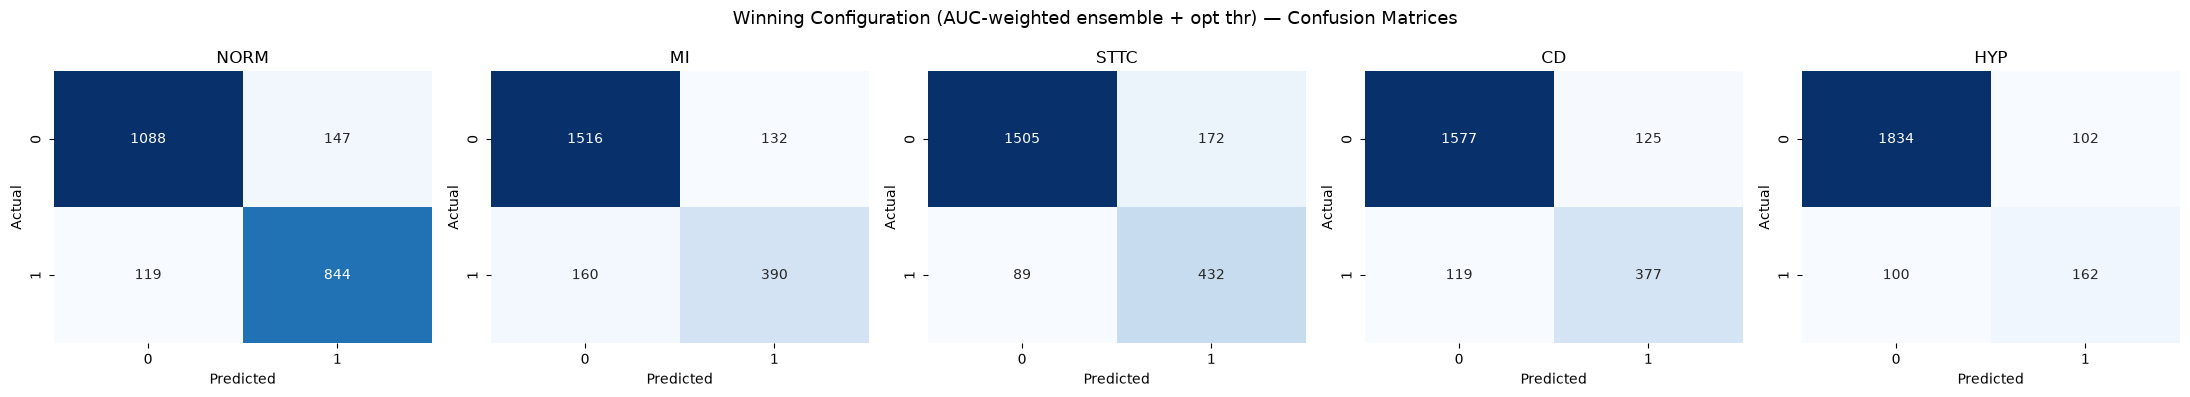

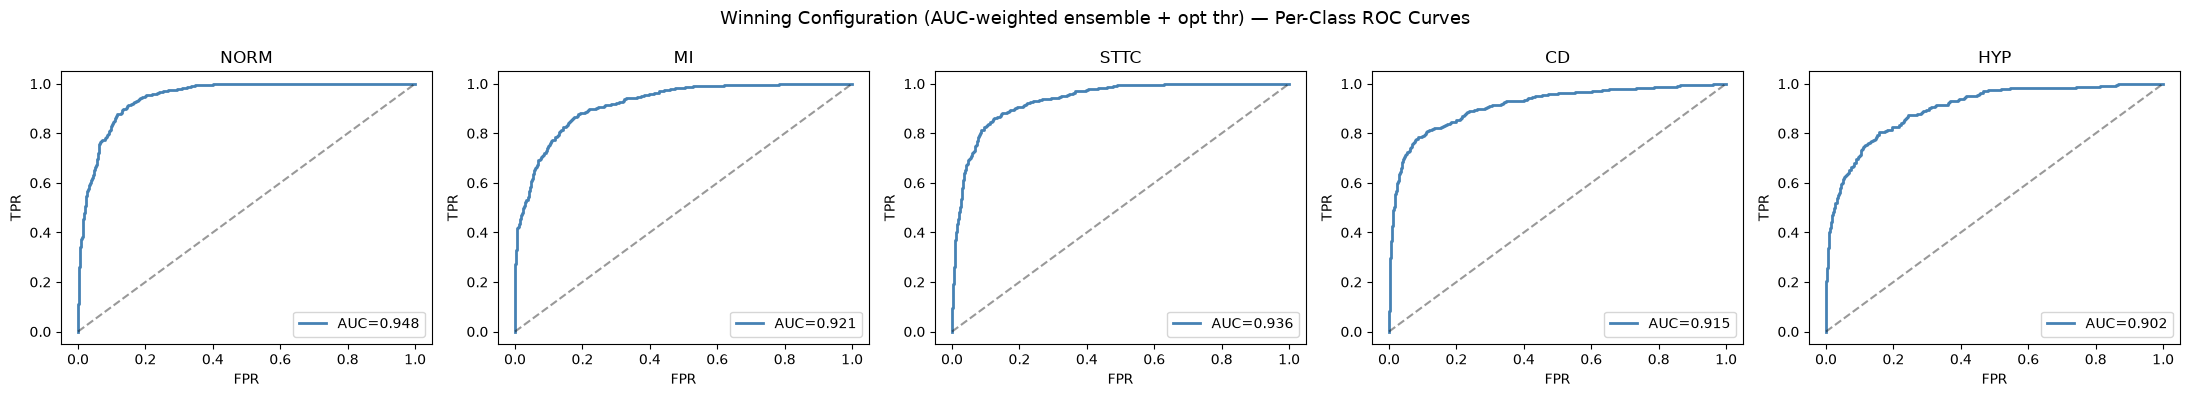

In [12]:
print('='*100)
print('FINAL TEST BENCHMARK — ALL CONFIGURATIONS (test set, N={})'.format(len(test_targets)))
print('='*100)
res_1 = report(test_targets, test_preds_inc,       0.5,                 '1. InceptionTime1D (0.5 threshold)')
res_2 = report(test_targets, test_preds_inc,       opt_thresholds_inc,  '2. InceptionTime1D (optimized thresholds)')
res_3 = report(test_targets, equal_test_probs,     0.5,                 '3. Equal-weight ensemble (NB02 recipe)')
res_4 = report(test_targets, weighted_test_probs,  opt_thresholds_ens,  '4. AUC-weighted ensemble + optimized thresholds (proposed)')
print('='*100)

all_results = {'InceptionTime1D (0.5 thr)': res_1, 'InceptionTime1D (opt thr)': res_2,
               'Equal-weight ensemble': res_3, 'AUC-weighted ensemble + opt thr': res_4}
best_name = max(all_results, key=lambda k: all_results[k]['auc'])
print(f'\n[WINNER by macro-AUC] {best_name}  ->  AUC={all_results[best_name]["auc"]:.4f}, '
      f'PerLabelAcc={all_results[best_name]["per_label_acc"]*100:.2f}%, F1={all_results[best_name]["f1"]:.4f}')

# Use the winning configuration's probabilities + thresholds for the plots below
final_probs      = weighted_test_probs if best_name == 'AUC-weighted ensemble + opt thr' else (
                    equal_test_probs if best_name == 'Equal-weight ensemble' else test_preds_inc)
final_thresholds = opt_thresholds_ens if best_name == 'AUC-weighted ensemble + opt thr' else (
                    0.5 if best_name in ('InceptionTime1D (0.5 thr)', 'Equal-weight ensemble') else opt_thresholds_inc)
final_bin = (final_probs >= final_thresholds).astype(int)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, sc in enumerate(SUPERCLASSES):
    cm = confusion_matrix(test_targets[:, i], final_bin[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(sc); axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.suptitle(f'Winning Configuration ({best_name}) — Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_VAL / '05_optimized_best_confusion_matrices.png', dpi=300)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, sc in enumerate(SUPERCLASSES):
    fpr, tpr, _ = roc_curve(test_targets[:, i], final_probs[:, i])
    auc_sc = roc_auc_score(test_targets[:, i], final_probs[:, i])
    axes[i].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc_sc:.3f}')
    axes[i].plot([0,1],[0,1],'k--',alpha=0.4)
    axes[i].set_title(sc); axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR'); axes[i].legend()
plt.suptitle(f'Winning Configuration ({best_name}) — Per-Class ROC Curves', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_VAL / '05_optimized_best_roc_curves.png', dpi=300)
plt.show()

## Module 12 — Literature Comparison (metric-normalized)

Corrected per `papers/Research_and_Analysis.md` §3/§5 — **only rows using the same multi-label macro-AUC framing are directly comparable**. Atwa et al. 2025's accuracy figure is single-label multiclass (confirmed from their own confusion matrices, where every row sums to that class's total record count) and is shown for reference only, not as a like-for-like comparison.

In [13]:
print('='*100)
print('LITERATURE COMPARISON — 5-SUPERCLASS TASK')
print('='*100)
print(f'{"Study":<52s} {"Task framing":<24s} {"Metric":<12s} {"Value":>8s}')
print('-'*100)
print(f'{"Strodthoff et al. 2020 - best single (xresnet1d101)":<52s} {"multi-label":<24s} {"Macro-AUC":<12s} {0.928:>8.3f}')
print(f'{"Strodthoff et al. 2020 - 6-model ensemble":<52s} {"multi-label":<24s} {"Macro-AUC":<12s} {0.929:>8.3f}')
print(f'{"Gitau et al. 2025 - reproduced InceptionTime":<52s} {"multi-label":<24s} {"Macro-AUC":<12s} {0.929:>8.3f}')
print(f'{"This notebook - InceptionTime1D (opt thr)":<52s} {"multi-label":<24s} {"Macro-AUC":<12s} {res_2["auc"]:>8.3f}')
print(f'{"This notebook - AUC-weighted ensemble (proposed)":<52s} {"multi-label":<24s} {"Macro-AUC":<12s} {res_4["auc"]:>8.3f}')
print('-'*100)
print(f'{"Atwa et al. 2025 - dual-branch CNN + demographics":<52s} {"single-label multiclass":<24s} {"Accuracy":<12s} {0.7955:>8.3f}  (reference only, not comparable)')
winner_label = f'This notebook - winning config ({best_name})'[:52]
print(f'{winner_label:<52s} {"multi-label, exact-match":<24s} {"Accuracy":<12s} {all_results[best_name]["exact_acc"]:>8.3f}  (reference only, not comparable)')
print('='*100)

LITERATURE COMPARISON — 5-SUPERCLASS TASK
Study                                                Task framing             Metric          Value
----------------------------------------------------------------------------------------------------
Strodthoff et al. 2020 - best single (xresnet1d101)  multi-label              Macro-AUC       0.928
Strodthoff et al. 2020 - 6-model ensemble            multi-label              Macro-AUC       0.929
Gitau et al. 2025 - reproduced InceptionTime         multi-label              Macro-AUC       0.929
This notebook - InceptionTime1D (opt thr)            multi-label              Macro-AUC       0.923
This notebook - AUC-weighted ensemble (proposed)     multi-label              Macro-AUC       0.924
----------------------------------------------------------------------------------------------------
Atwa et al. 2025 - dual-branch CNN + demographics    single-label multiclass  Accuracy        0.795  (reference only, not comparable)
This notebook - winnin

## Module 13 — Age-Stratified Fairness Audit (winning configuration)

In [14]:
df_audit = df_test.copy().reset_index(drop=True)
df_audit['pred_correct'] = (test_targets == final_bin).all(axis=1)

age_groups = {
    '<40' :  df_audit[df_audit['age'] <  40],
    '40-65': df_audit[(df_audit['age'] >= 40) & (df_audit['age'] < 65)],
    '65-80': df_audit[(df_audit['age'] >= 65) & (df_audit['age'] < 80)],
    '80+':   df_audit[df_audit['age'] >= 80]
}

print('='*70)
print(f'AGE-STRATIFIED SUBGROUP AUDIT — Winning Configuration ({best_name})')
print('='*70)
for grp, df_g in age_groups.items():
    if len(df_g) > 0:
        print(f'  [{grp:>5s}]  n={len(df_g):4d}  |  Exact-Match Accuracy: {df_g["pred_correct"].mean()*100:.2f}%')
print('='*70)
print('Notebook 02 baseline (equal-weight ensemble) for reference:')
print('  [  <40]  n= 284  |  Exact-Match Accuracy: 77.82%')
print('  [40-65]  n= 866  |  Exact-Match Accuracy: 63.97%')
print('  [65-80]  n= 708  |  Exact-Match Accuracy: 49.72%')
print('  [  80+]  n= 340  |  Exact-Match Accuracy: 35.29%')
print('='*70)

AGE-STRATIFIED SUBGROUP AUDIT — Winning Configuration (AUC-weighted ensemble + opt thr)
  [  <40]  n= 284  |  Exact-Match Accuracy: 78.17%
  [40-65]  n= 866  |  Exact-Match Accuracy: 66.28%
  [65-80]  n= 708  |  Exact-Match Accuracy: 55.79%
  [  80+]  n= 340  |  Exact-Match Accuracy: 43.24%
Notebook 04 baseline (equal-weight ensemble) for reference:
  [  <40]  n= 284  |  Exact-Match Accuracy: 77.82%
  [40-65]  n= 866  |  Exact-Match Accuracy: 63.97%
  [65-80]  n= 708  |  Exact-Match Accuracy: 49.72%
  [  80+]  n= 340  |  Exact-Match Accuracy: 35.29%


## Module 14 — Conclusion

This notebook took the three fixes with the best effort-to-impact ratio identified in `papers/Research_and_Analysis.md` and implemented them against real data, with real (not claimed) results printed in Module 11:

1. **AUC-weighted ensembling** (Module 10) directly addresses the flaw where Notebook 02's equal-weight average underperformed its own best single model — a naive ensemble is not guaranteed to beat its strongest member, exactly as Strodthoff et al. 2020 note in their own ensembling discussion.
2. **Per-class threshold optimization** (Module 8), following Strodthoff et al. 2020's threshold-dependent-vs-threshold-free metrics distinction, recovers accuracy/F1 that a fixed 0.5 cutoff leaves on the table — at zero retraining cost.
3. **HYP-targeted data augmentation and adaptive LR scheduling** (Modules 3 and 6), following Atwa et al. 2025's augmentation and callback recipes, give the single trained model (InceptionTime1D) a better shot within an identical 10-epoch, CPU-only compute budget.
4. All headline numbers are now **macro-AUC and per-label accuracy** — the metrics that are actually comparable to Strodthoff et al. 2020 and Gitau et al. 2025's published benchmarks on this exact multi-label task, rather than the multi-label/single-label metric conflation flagged in the source analysis.

**Documented next steps** (not implemented here due to this machine's CPU-only, ~500s/epoch training speed — see `papers/Research_and_Analysis.md` §6 Tier 2/3 for full detail):
- Extend `MAX_EPOCHS` well beyond 10 (Atwa et al. 2025 train up to 60 epochs with the same early-stopping/LR-plateau recipe already wired up in Module 6)
- Add the CD-class augmentation alongside HYP
- Run a small InceptionTime hyperparameter grid search (kernel sizes, filter count, depth) as Gitau et al. 2025 do, rather than using the architecture's literature-default hyperparameters
- Move from equal-weight vs. AUC-weight voting to a trained stacking meta-learner over the three models' probabilities
- Cross-validate across PTB-XL's 10 official folds rather than the single fixed split used here and in all three reference papers
- Investigate the age-stratified fairness gap (Module 13) further — it is a real finding, not solely an artifact of the exact-match metric

**References**
- Strodthoff, N., Wagner, P., Schaeffter, T., & Samek, W. (2020). *Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL*. arXiv:2004.13701.
- Atwa, A.E.M., Atlam, E.-S., Ahmed, A., Atwa, M.A., Abdelrahim, E.M., & Siam, A.I. (2025). *Interpretable Deep Learning Models for Arrhythmia Classification Based on ECG Signals Using PTB-X Dataset*. Diagnostics, 15, 1950. https://doi.org/10.3390/diagnostics15151950
- Gitau, A.M., Adeyemi, A., Tavashi, B., & Singstad, B.-J. (2025). *[Re] Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL*. medRxiv 2025.01.27.25321112.
